# Análisis Exploratorio de los Datos - EDA
---

In [ ]:
# Imports
import sys
import pandas as pd
import numpy as np
from pathlib import Path

In [ ]:
# Ruta raíz del proyecto (cwd = donde se encuentra el notebook; .parent = ruta padre, eso da la ruta raíz)
PROJECT_ROOT = Path.cwd().parent

# Agrega la raíz del repositorio a sys.path para poder importar desde src/.
sys.path.append(str(PROJECT_ROOT))

# Ruta del dataset procesado
PROCESSED_PATH = PROJECT_ROOT / "data" / "processed" / "bank_marketing.csv"
df = pd.read_csv(PROCESSED_PATH)

### 1. Balance de la variable objetivo

Se analiza la distribución de la variable objetivo `y` para determinar si existe un desbalance entre las clases `yes` y `no`. Este análisis es relevante para definir la estrategia de evaluación y entrenamiento de los modelos predictivos.

In [4]:
# Distribución de la variable objetivo

conteo_y = df["y"].value_counts()
porcentaje_y = df["y"].value_counts(normalize=True) * 100

print("Cantidad de registros por clase:")
print(conteo_y)

print("\nPorcentaje de registros por clase:")
print(porcentaje_y.round(2))

Cantidad de registros por clase:
y
no     39922
yes     5289
Name: count, dtype: int64

Porcentaje de registros por clase:
y
no     88.3
yes    11.7
Name: proportion, dtype: float64


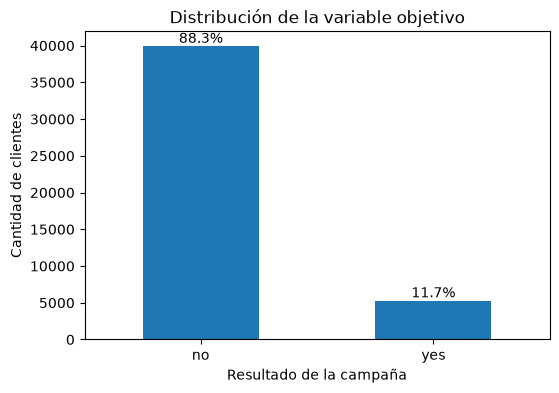

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))

ax = conteo_y.plot(kind="bar")

plt.title("Distribución de la variable objetivo")
plt.xlabel("Resultado de la campaña")
plt.ylabel("Cantidad de clientes")
plt.xticks(rotation=0)

for i, valor in enumerate(conteo_y):
    porcentaje = porcentaje_y.iloc[i]
    ax.text(i, valor, f"{porcentaje:.1f}%", ha="center", va="bottom")

plt.show()

**Interpretación**

La variable objetivo presenta un desbalance considerable. El 88.3% de los clientes no aceptó la oferta (`no`), mientras que solamente el 11.7% la aceptó (`yes`). Esto significa que la clase positiva es minoritaria y que un modelo podría favorecer la clase `no` si se evalúa únicamente mediante Accuracy.

**Decisión de modelado**

Debido al desbalance observado, la evaluación de los modelos no se basará únicamente en Accuracy. Se utilizarán métricas como Precision, Recall, F1-score y ROC-AUC para evaluar adecuadamente la capacidad del modelo para identificar la clase `yes`. Además, se evaluará el uso de ponderación de clases durante el entrenamiento.

---

### 2. Distribución de Variables Númericas

Se analiza la distribución de las variables numéricas para identificar diferencias de escala, asimetrías y concentraciones de valores que puedan influir en el preprocesamiento y selección de los modelos.

In [6]:
# Identificar variables numéricas

variables_numericas = df.select_dtypes(include="number").columns

print("Variables numéricas:")
print(list(variables_numericas))

Variables numéricas:
['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']


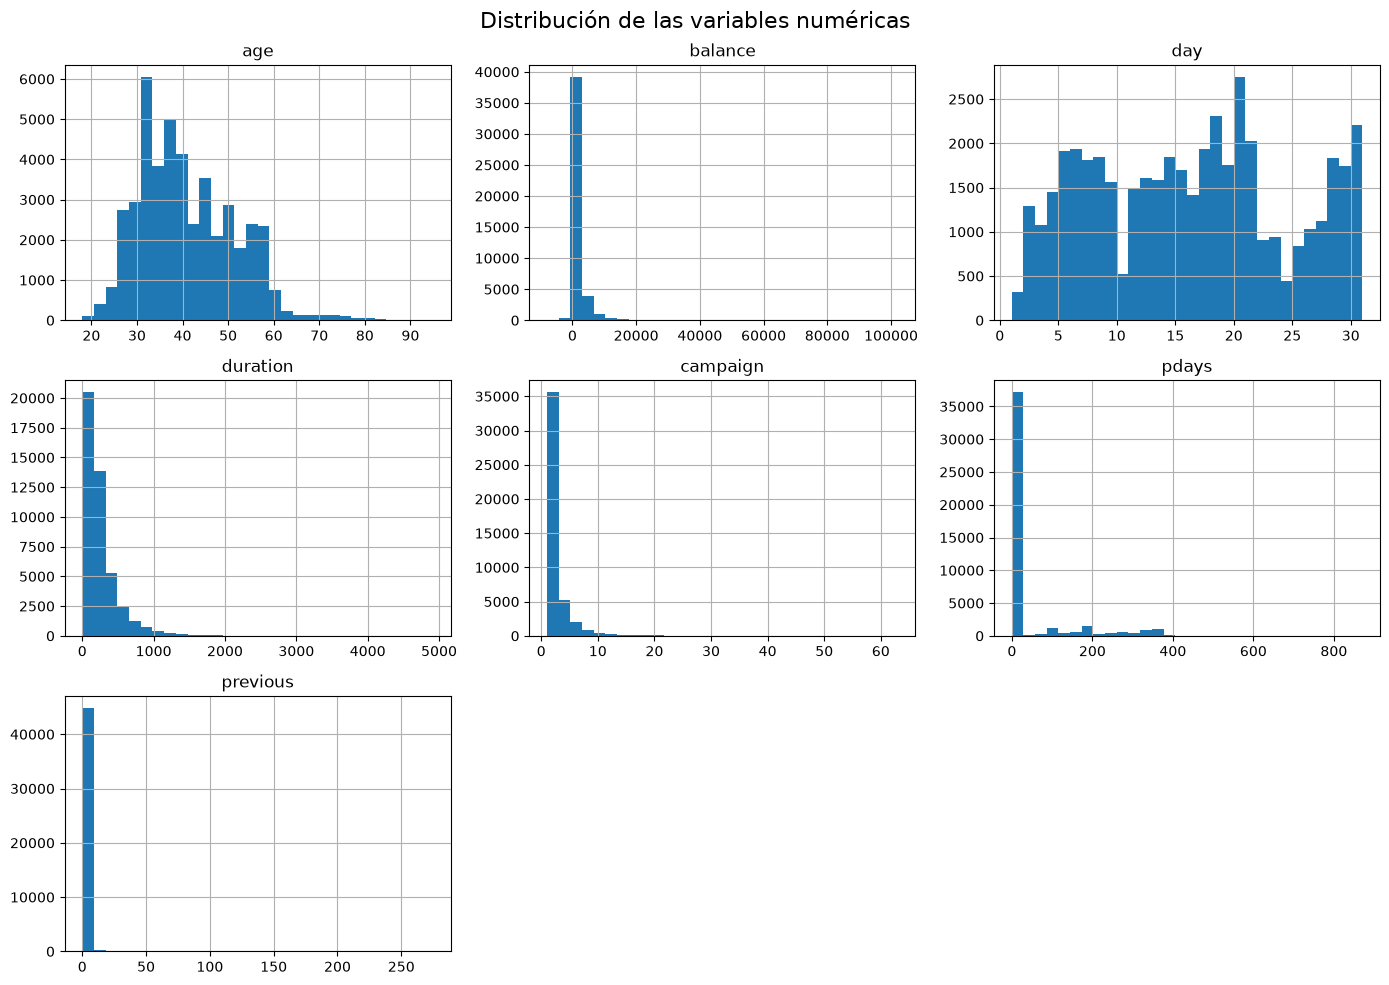

In [7]:
df[variables_numericas].hist(
    figsize=(14, 10),
    bins=30
)

plt.suptitle("Distribución de las variables numéricas", fontsize=16)
plt.tight_layout()
plt.show()

**Interpretación**

Las variables numéricas presentan distribuciones diferentes. `age` muestra una concentración principalmente entre los 25 y 60 años, mientras que `day` presenta una distribución irregular a lo largo del mes.

Por otro lado, `balance`, `duration`, `campaign`, `pdays` y `previous` presentan distribuciones asimétricas, con una alta concentración de observaciones en valores bajos y colas hacia valores superiores. Este comportamiento es especialmente evidente en `balance`, `campaign` y `previous`.

En `pdays` se observa una concentración muy elevada en los valores cercanos a cero; sin embargo, el histograma general no permite distinguir adecuadamente el valor `-1`, que representa la ausencia de contacto previo. Por esta razón, esta variable requiere un análisis específico.

`duration` también presenta una distribución fuertemente sesgada y, además, deberá analizarse posteriormente desde el punto de vista de posible data leakage.

**Decisión**

No se eliminarán variables ni valores extremos únicamente por la forma de sus distribuciones, ya que estos pueden representar situaciones reales de los clientes.

Las variables numéricas se conservarán para el modelado. Durante el feature engineering se evaluará la necesidad de estandarización, especialmente para modelos sensibles a la escala.

Además, se realizará un análisis específico de `pdays` debido al significado del valor `-1`, y se evaluará `duration` posteriormente para determinar si debe excluirse por posible data leakage, igualmente en el feature engineering.

---

### 3. Relación entre variable númericas y la variable objetivo

Se comparan las variables numéricas entre las clases de la variable objetivo para identificar diferencias en el comportamiento de los clientes que aceptaron y no aceptaron la oferta. Se utiliza la mediana como medida de comparación debido a la presencia de distribuciones asimétricas y valores extremos.

In [8]:
# Comparación de las medianas según la variable objetivo

medianas_por_y = df.groupby("y")[variables_numericas].median().T

print(medianas_por_y)

y            no    yes
age        39.0   38.0
balance   417.0  733.0
day        16.0   15.0
duration  164.0  426.0
campaign    2.0    2.0
pdays      -1.0   -1.0
previous    0.0    0.0


In [9]:
# Diferencia entre las medianas de yes y no

diferencia_medianas = medianas_por_y["yes"] - medianas_por_y["no"]

print("Diferencia de medianas (yes - no):")
print(diferencia_medianas.sort_values(ascending=False))

Diferencia de medianas (yes - no):
balance     316.0
duration    262.0
campaign      0.0
pdays         0.0
previous      0.0
day          -1.0
age          -1.0
dtype: float64


**Interpretación**

La comparación de medianas muestra las mayores diferencias entre las clases en `balance` y `duration`. La mediana de `balance` es 316 unidades mayor en los clientes que aceptaron la oferta, mientras que `duration` presenta una diferencia de 262 segundos.

En `age` y `day` la diferencia es mínima, de apenas una unidad, y `campaign` presenta la misma mediana en ambas clases. En `pdays` y `previous` tampoco se observan diferencias en la mediana, debido principalmente a la alta concentración de valores en `-1` y `0`, respectivamente.

Estas diferencias descriptivas permiten identificar variables que pueden ser relevantes para continuar el análisis, pero por sí solas no permiten determinar su capacidad predictiva.

**Decisión**

Se mantendrán las variables numéricas para continuar evaluando su relación con la variable objetivo.

`balance` y `duration` serán analizadas con mayor detalle debido a las diferencias observadas entre las clases. `pdays` y `previous` requieren un análisis específico debido a sus valores especiales y a la concentración de observaciones.

No se eliminarán variables únicamente a partir de las diferencias de medianas, se considerará el escalado o transformación en el feature engineering de acuerdo al modelo a utilizar.

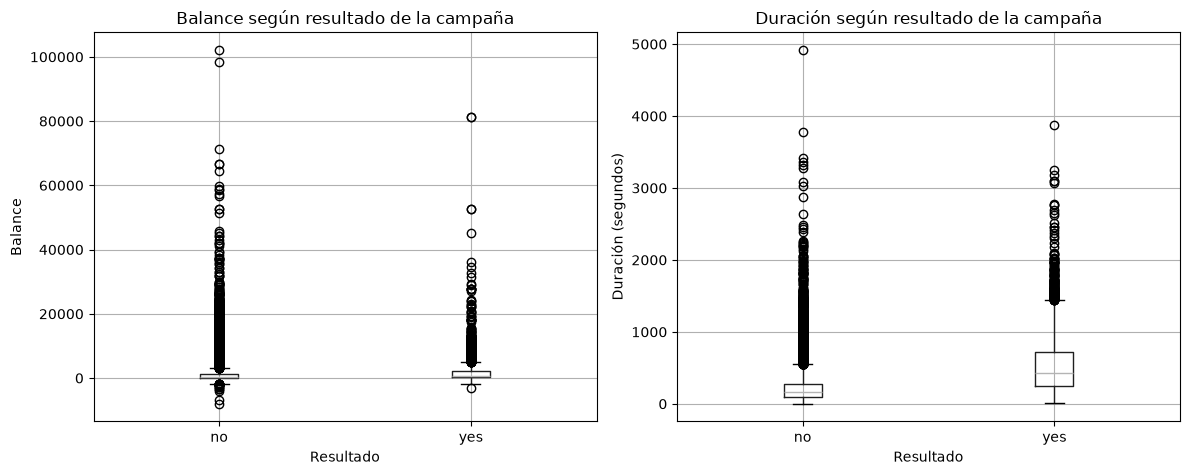

In [ ]:
# Distribución de variables numéricas según el target (balance y duration)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

df.boxplot(column="balance", by="y", ax=axes[0])
axes[0].set_title("Balance según resultado de la campaña")
axes[0].set_xlabel("Resultado")
axes[0].set_ylabel("Balance")

df.boxplot(column="duration", by="y", ax=axes[1])
axes[1].set_title("Duración según resultado de la campaña")
axes[1].set_xlabel("Resultado")
axes[1].set_ylabel("Duración (segundos)")

plt.suptitle("")
plt.tight_layout()
plt.show()

**Interpretación**

El boxplot de `balance` muestra una distribución altamente dispersa y con numerosos valores extremos en ambas clases. La clase `yes` presenta una mediana superior a `no`, aunque existe un amplio solapamiento entre ambas distribuciones. Por lo tanto, aunque el balance presenta diferencias entre los grupos, los valores por sí solos no permiten una separación clara entre clientes que aceptan y no aceptan la oferta.

En `duration` se observa una diferencia más marcada entre las clases. Los clientes que aceptaron la oferta (`yes`) presentan una mediana y una distribución de duraciones claramente superiores a los clientes que no la aceptaron (`no`). También se observan numerosos valores extremos en ambas clases.

Sin embargo, esta relación debe interpretarse con precaución, ya que `duration` corresponde a la duración de la llamada y su valor solamente se conoce durante o después de la interacción con el cliente.

**Decisión**

Se conservará `balance` como variable predictora y no se eliminarán automáticamente sus valores extremos, ya que pueden representar situaciones reales de los clientes. Su comportamiento será considerado durante el feature engineering y modelado.

Aunque `duration` presenta una fuerte relación con el resultado de la campaña, se considera una variable con potencial de data leakage para un modelo que pretenda predecir la aceptación antes o al inicio de la llamada. Por esta razón, se mantiene la decisión de excluirla de las variables predictoras en la etapa de modelado.

---

### 4. Relación entre variables categóricas y la variable objetivo

Se analiza la relación entre las variables categóricas y la variable objetivo `y` mediante la tasa de aceptación de cada categoría. El objetivo es identificar si existen diferencias en la probabilidad de contratación entre los distintos grupos de clientes y determinar si estas variables aportan información relevante para el modelado.

In [11]:
# Variables categóricas

variables_categoricas = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome"
]

print("Variables categóricas:")
print(variables_categoricas)

Variables categóricas:
['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'poutcome']


In [12]:
# Tasa de aceptación por categoría

for col in variables_categoricas:
    
    tasa = pd.crosstab(
        df[col],
        df["y"],
        normalize="index"
    ) * 100
    
    print(f"\n--- {col} ---")
    print(tasa.round(2))


--- job ---
y                 no    yes
job                        
admin.         87.80  12.20
blue-collar    92.73   7.27
entrepreneur   91.73   8.27
housemaid      91.21   8.79
management     86.24  13.76
retired        77.21  22.79
self-employed  88.16  11.84
services       91.12   8.88
student        71.32  28.68
technician     88.94  11.06
unemployed     84.50  15.50
unknown        88.19  11.81

--- marital ---
y            no    yes
marital               
divorced  88.05  11.95
married   89.88  10.12
single    85.05  14.95

--- education ---
y             no    yes
education              
primary    91.37   8.63
secondary  89.44  10.56
tertiary   84.99  15.01
unknown    86.43  13.57

--- default ---
y           no    yes
default              
no       88.20  11.80
yes      93.62   6.38

--- housing ---
y          no   yes
housing            
no       83.3  16.7
yes      92.3   7.7

--- loan ---
y        no    yes
loan              
no    87.34  12.66
yes   93.32   6.68

--- con

**Interpretación**

Se observan diferencias en la tasa de aceptación entre las categorías de varias variables. Las diferencias más marcadas aparecen en `poutcome`, `month` y `job`, mientras que `marital` presenta diferencias más pequeñas entre sus categorías. También se observan diferencias en `housing`, `loan` y `contact`, aunque de menor magnitud.

**Decisión**

Se conservarán las variables categóricas para el modelado, ya que algunas muestran diferencias relevantes en la tasa de aceptación. Se profundizará principalmente en `poutcome`, `month` y `job`, mientras que las variables con diferencias menores se mantendrán sin realizar análisis adicionales por el momento.

**Análisis `poutcome`**

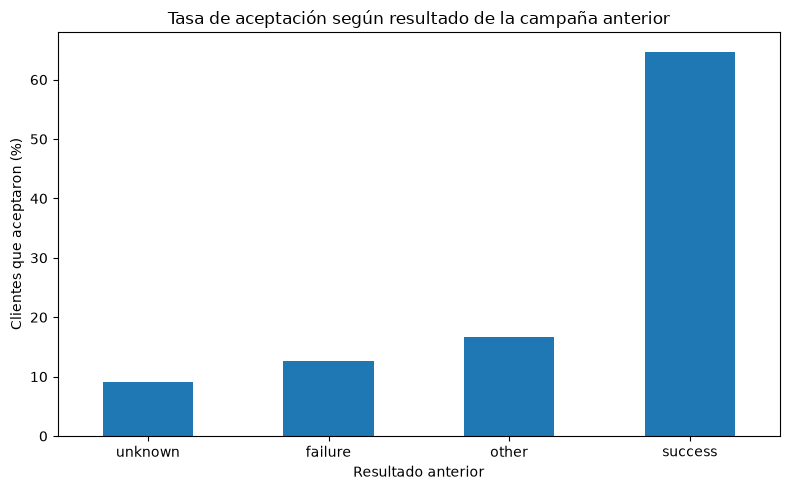

In [13]:
# Tasa de aceptación según el resultado de la campaña anterior

tasa_poutcome = pd.crosstab(
    df["poutcome"],
    df["y"],
    normalize="index"
) * 100

tasa_poutcome["yes"].sort_values().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Tasa de aceptación según resultado de la campaña anterior")
plt.xlabel("Resultado anterior")
plt.ylabel("Clientes que aceptaron (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

**Interpretación**

El resultado de la campaña anterior presenta una relación importante con la aceptación de la campaña actual. Los clientes con `poutcome = success` alcanzan una tasa de aceptación de 64.73%, muy superior al resto de categorías, que se mantienen por debajo del 17%.

In [14]:
# Relación entre contactos previos y resultado de la campaña anterior

pd.crosstab(
    df["previous"] > 0,
    df["poutcome"],
    normalize="index"
).round(3)

poutcome,failure,other,success,unknown
previous,,,,
False,0.000,0.000,0.000,1.000
True,0.594,0.223,0.183,0.001


In [15]:
# Casos donde no hubo contactos previos pero aparece un resultado de campaña anterior

casos_inconsistentes = df[
    (df["previous"] == 0) &
    (df["poutcome"] != "unknown")
]

print("Casos:", len(casos_inconsistentes))

Casos: 0


**Decisión**

Se conservará `poutcome` como variable predictora debido a su fuerte relación con el objetivo. La validación realizada no evidencia inconsistencias temporales ni una fuga de información en esta variable, ya que representa resultados de campañas anteriores. Desde el punto de vista de negocio, puede ser útil para priorizar clientes con antecedentes favorables.

**Análisis de `month`**

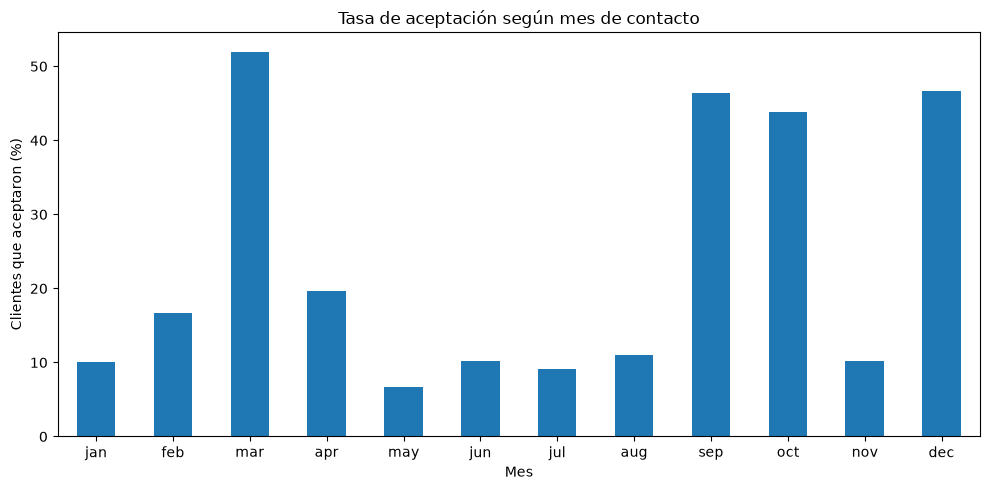

In [17]:
# Orden cronológico de los meses
orden_meses = [
    "jan", "feb", "mar", "apr", "may", "jun",
    "jul", "aug", "sep", "oct", "nov", "dec"
]

# Calcular tasa de aceptación
tasa_month = pd.crosstab(
    df["month"],
    df["y"],
    normalize="index"
) * 100

# Reordenar según el calendario
tasa_month = tasa_month.reindex(orden_meses)

# Graficar
tasa_month["yes"].plot(
    kind="bar",
    figsize=(10, 5)
)

plt.title("Tasa de aceptación según mes de contacto")
plt.xlabel("Mes")
plt.ylabel("Clientes que aceptaron (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

**Interpretación**

La tasa de aceptación presenta diferencias importantes entre los meses. Marzo muestra la tasa más alta, con aproximadamente 52%, seguido de diciembre, septiembre y octubre.

No se observa un patrón estrictamente creciente o decreciente a lo largo del año, pero sí existen meses con comportamientos claramente diferenciados.

**Decisión**

Se conservará `month` como variable predictora, ya que presenta diferencias importantes en la tasa de aceptación. Esta variable podría aportar información útil para el modelo y, desde el punto de vista de negocio, permitir identificar períodos con mayor potencial de respuesta.

Sin embargo, las diferencias observadas no permiten afirmar que el mes sea la causa de una mayor aceptación, por lo que se validará su importancia durante el modelado.

**Análisis de `job`**

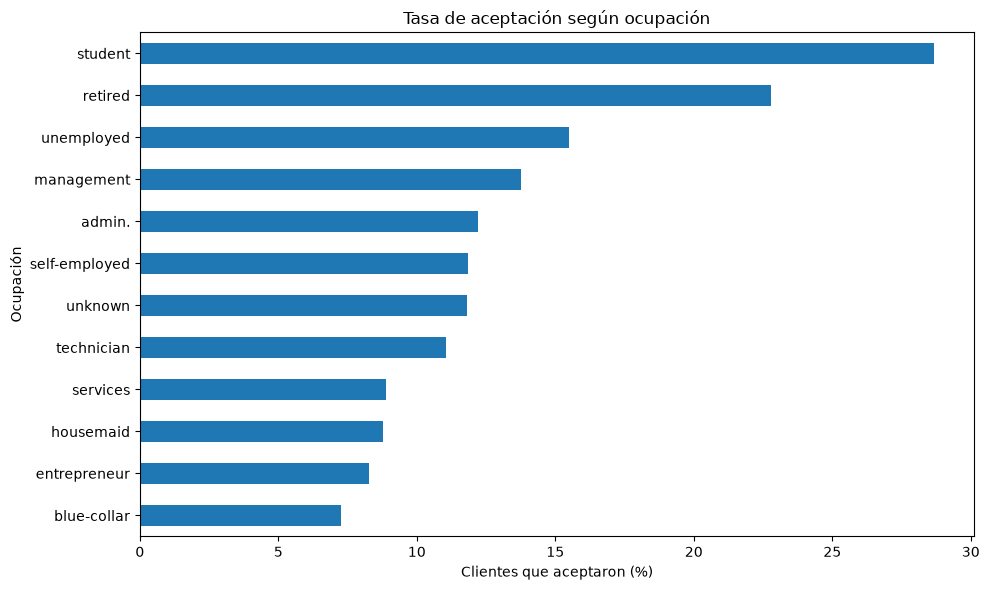

In [18]:
# Tasa de aceptación según ocupación

tasa_job = pd.crosstab(
    df["job"],
    df["y"],
    normalize="index"
) * 100

tasa_job["yes"].sort_values().plot(
    kind="barh",
    figsize=(10, 6)
)

plt.title("Tasa de aceptación según ocupación")
plt.xlabel("Clientes que aceptaron (%)")
plt.ylabel("Ocupación")

plt.tight_layout()
plt.show()

**Interpretación**

La tasa de aceptación presenta diferencias importantes según la ocupación. Los clientes `student` y `retired` muestran las tasas más altas, con aproximadamente 28.7% y 22.8%, mientras que `blue-collar` y `entrepreneur` presentan las más bajas, con 7.3% y 8.3%.

Esto indica que la ocupación está asociada con diferentes niveles de respuesta a la campaña. Sin embargo, estas diferencias no implican que la ocupación sea la causa de una mayor o menor aceptación.

**Decisión**

Se conservará `job` como variable predictora, ya que presenta diferencias relevantes en la tasa de aceptación. No se agruparán las categorías únicamente por sus tasas de respuesta, pues cada ocupación representa un segmento distinto y la importancia de la variable será validada posteriormente durante el modelado.

Desde el punto de vista de negocio, las diferencias observadas pueden utilizarse para identificar segmentos con mayor potencial de respuesta y orientar futuras estrategias de contacto.

---

### 5. Detección de potencial Data Leakage

Se revisan las variables que podrían contener información que no estaría disponible en el momento en que se desea realizar la predicción. El objetivo es evitar que el modelo utilice información generada después del momento de predicción y obtenga un desempeño artificialmente elevado.

In [20]:
# Variables relacionadas con el contacto actual

variables_contacto = ["day", "month", "duration", "campaign"]

df[variables_contacto].head()

,day,month,duration,campaign
0,5,may,261,1
1,5,may,151,1
2,5,may,76,1
3,5,may,92,1
4,5,may,198,1


In [21]:
# Comparación de duration según el resultado de la campaña

df.groupby("y")["duration"].agg(
    ["count", "mean", "median", "min", "max"]
).round(2)

,count,mean,median,min,max
y,,,,,
no,39922,221.18,164.0,0,4918
yes,5289,537.29,426.0,8,3881


In [22]:
# Variables que serán excluidas del conjunto de predictores
variables_excluir = ["duration"]

print("Variables excluidas por potencial data leakage:")
print(variables_excluir)

Variables excluidas por potencial data leakage:
['duration']


**Interpretación**

`duration` presenta una relación fuerte con la variable objetivo, pero su valor solamente se conoce durante o después del contacto con el cliente. Por lo tanto, si el objetivo es predecir la aceptación antes de realizar la llamada, esta variable contiene información que no estaría disponible en el momento de predicción.

**Decisión**

Se excluirá `duration` de las variables predictoras del modelo principal para evitar data leakage. La variable se conservará en el dataset original para fines de análisis y trazabilidad, pero no se utilizará como predictor.

---

### 6. Evaluación de Multicolinealidad

Se evalúa la multicolinealidad entre las variables numéricas para identificar si existen variables que contienen información excesivamente similar entre sí. Esto es importante porque una alta relación entre variables puede afectar la estabilidad e interpretación de algunos modelos predictivos, especialmente los modelos lineales.

Para identificar este posible problema se utilizará el Factor de Inflación de la Varianza (VIF), que permite evaluar cuánto aumenta la varianza de una variable debido a su relación con las demás variables predictoras.

In [35]:
variables_vif = [
    "age",
    "balance",
    "day",
    "campaign",
    "pdays",
    "previous"
]

X_vif = df[variables_vif].copy()

In [36]:
matriz_corr = X_vif.corr()

In [37]:
# Inversa de la matriz de correlaciones
matriz_inversa = np.linalg.inv(matriz_corr.values)

vif = pd.DataFrame({
    "variable": variables_vif,
    "VIF": np.diag(matriz_inversa)
})

vif = vif.sort_values("VIF", ascending=False)

vif.round(2)

,variable,VIF
4,pdays,1.28
5,previous,1.26
2,day,1.03
3,campaign,1.03
0,age,1.01
1,balance,1.01


**Interpretación**

Los valores de VIF obtenidos son bajos para todas las variables analizadas. `pdays` presenta el valor más alto (1.28), seguido de `previous` (1.26), pero ambos se encuentran en un rango que no evidencia problemas importantes de multicolinealidad. El resto de las variables presenta valores cercanos a 1, indicando poca relación lineal entre los predictores.

**Decisión**

Se conservarán las variables numéricas analizadas, ya que no se identificó una multicolinealidad que justifique eliminar o combinar variables. Aunque `pdays` y `previous` presentan los valores más altos, su relación no representa un problema para el modelado.

---

### 7. Skewness y Kurtosis de las variables númericas

Se analiza la asimetría y la curtosis de las variables numéricas para identificar distribuciones alejadas de la normalidad y determinar si existen variables con una concentración importante de valores extremos. Este análisis permitirá evaluar posteriormente si alguna variable requiere una transformación antes del modelado.

In [38]:
variables_numericas_modelo = [
    "age",
    "balance",
    "day",
    "campaign",
    "pdays",
    "previous"
]

skew_kurt = pd.DataFrame({
    "Skewness": df[variables_numericas_modelo].skew(),
    "Kurtosis": df[variables_numericas_modelo].kurtosis()
})

skew_kurt.round(2)

,Skewness,Kurtosis
age,0.68,0.32
balance,8.36,140.75
day,0.09,-1.06
campaign,4.90,39.25
pdays,2.62,6.94
previous,41.85,4506.86


**Interpretación**

Se observa una distribución aproximadamente simétrica en `day` (skewness = 0.09) y una asimetría moderada en `age` (0.68). En cambio, `balance`, `campaign`, `pdays` y especialmente `previous` presentan una fuerte asimetría positiva y valores elevados de curtosis, lo que indica una alta concentración de observaciones en valores bajos y la presencia de colas largas y valores extremos. Estos resultados son consistentes con las distribuciones observadas anteriormente.

**Decisión**

No se realizarán transformaciones directamente sobre estas variables durante el EDA. Se conservarán para el modelado y se evaluará el uso de transformaciones y/o escalamiento durante el feature engineering, especialmente para `balance`, `campaign`, `pdays` y `previous`. La necesidad de transformar dependerá también del tipo de modelo utilizado.

---

### 8. Evaluación de escalas de las variables númericas

Se revisan las escalas de las variables numéricas para identificar diferencias importantes en sus rangos y determinar si será necesario estandarizar o normalizar los datos antes del modelado. Esto es especialmente relevante para modelos sensibles a la escala de las variables, como la regresión logística y KNN.

In [39]:
escala_variables = df[variables_numericas_modelo].agg(
    ["min", "max", "mean", "std"]
).T

escala_variables.round(2)

,min,max,mean,std
age,18.0,95.0,40.94,10.62
balance,-8019.0,102127.0,1362.27,3044.77
day,1.0,31.0,15.81,8.32
campaign,1.0,63.0,2.76,3.10
pdays,-1.0,871.0,40.20,100.13
previous,0.0,275.0,0.58,2.30


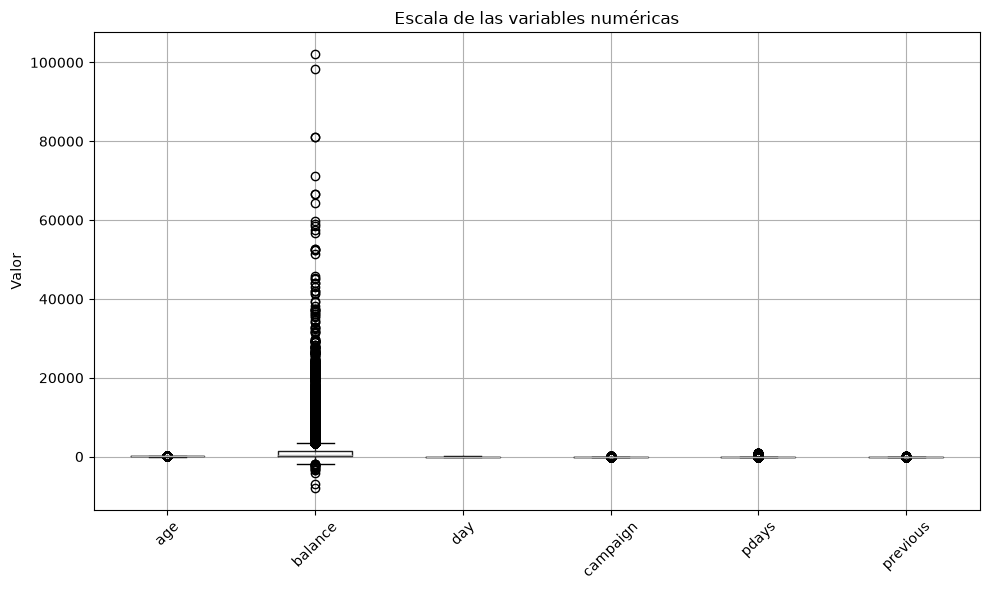

In [40]:
df[variables_numericas_modelo].boxplot(figsize=(10, 6))

plt.title("Escala de las variables numéricas")
plt.ylabel("Valor")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**Interpretación**

Las variables presentan diferencias importantes en sus escalas. `age` y `day` tienen rangos relativamente pequeños, mientras que `balance` y `pdays` presentan rangos mucho más amplios. También existen diferencias considerables en la desviación estándar entre las variables, por lo que algunas podrían tener mayor influencia en modelos sensibles a la escala.

**Decisión**

Se mantendrán las variables en sus escalas originales durante el EDA. Para el feature engineering se considerará la estandarización de las variables numéricas, especialmente para modelos sensibles a la escala como Regresión Logística, KNN o SVM. En modelos basados en árboles, el escalamiento no será necesario.

---

### 9. Resumen de hallazgos y decisiones

| Hallazgo | Decisión |
|---|---|
| La variable objetivo `y` presenta un desbalance importante, con una mayor proporción de casos `no`. | Considerar el desbalance durante el modelado y utilizar métricas como Precision, Recall y F1, además de evaluar estrategias como `class_weight`. |
| `balance` presenta diferencias entre los clientes que aceptaron y los que no aceptaron la oferta. | Mantener `balance` como variable predictora y considerar su distribución durante el preprocesamiento. |
| `duration` presenta una diferencia marcada entre las clases, pero su valor solo se conoce durante o después de la llamada. | Excluir `duration` del modelo principal para evitar data leakage. |
| `poutcome` presenta diferencias importantes en la tasa de aceptación según el resultado de campañas anteriores. | Mantener `poutcome` como variable predictora. |
| `month` presenta diferencias importantes en las tasas de aceptación entre meses. | Mantener `month` como predictor y considerar su posible utilidad para la planificación de campañas. |
| `job` presenta diferencias en la tasa de aceptación entre ocupaciones. | Mantener `job` como variable predictora. |
| Los valores de VIF son bajos para las variables numéricas. | No eliminar ni combinar variables numéricas por problemas de multicolinealidad. |
| `balance`, `campaign`, `pdays` y `previous` presentan una fuerte asimetría y colas largas. | Evaluar transformaciones durante el preprocesamiento según el modelo utilizado. |
| Las variables numéricas presentan escalas diferentes. | Considerar estandarización para modelos sensibles a la escala, como Regresión Logística, KNN o SVM. |